## CUSTODIAN STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

nahco=pd.read_csv('../stock_data/nahco.csv') ## so it can be small letter. This is cool.
nahco=nahco.drop(columns=['high_price','low_price'])
nahco.rename(columns={'trade_date':'date'},inplace=True)
nahco['date']=pd.to_datetime(nahco['date'])
nahco['month']=nahco['date'].dt.month
nahco['quarter']=nahco['date'].dt.quarter
nahco['year']=nahco['date'].dt.year

nahco

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42863,NAHCO,2017-01-03,3.16,3.16,34700,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43423,NAHCO,2017-01-04,3.16,3.16,29392,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43533,NAHCO,2017-01-05,2.86,2.86,191557,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43643,NAHCO,2017-01-06,2.72,2.72,239304,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43733,NAHCO,2017-01-09,2.59,2.59,252181,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298100,NAHCO,2026-07-13,177.00,177.00,1311168,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298538,NAHCO,2026-07-14,177.00,177.00,743509,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298976,NAHCO,2026-07-15,172.10,172.10,492065,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299414,NAHCO,2026-07-16,172.10,172.10,666466,2026-07-16T15:10:03.113936+00:00,7,3,2026


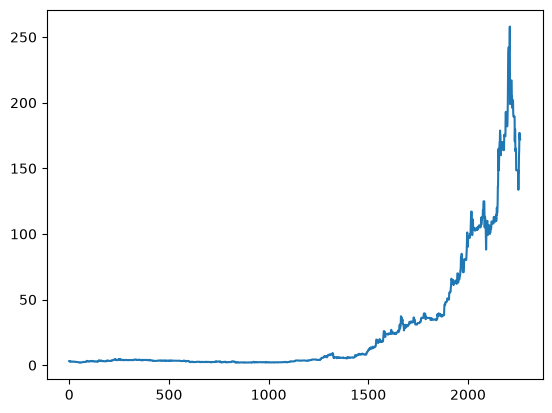

In [2]:
import matplotlib.pyplot as plt

plt.plot(nahco['close_price'])
plt.show()

In [3]:
nahco_end_month_df = (
    nahco
    .sort_values("date")
    .groupby(nahco["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

nahco_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45433,NAHCO,2017-01-31,2.71,2.71,38324,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47256,NAHCO,2017-02-28,2.45,2.45,71232,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49372,NAHCO,2017-03-31,2.10,2.10,596105,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51199,NAHCO,2017-04-28,2.50,2.50,2071926,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53122,NAHCO,2017-05-31,2.75,2.75,121475,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35337,NAHCO,2026-03-31,193.00,193.00,2175728,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281163,NAHCO,2026-04-30,258.00,258.00,5181038,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284229,NAHCO,2026-05-29,189.50,189.50,611268,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294157,NAHCO,2026-06-30,148.50,148.50,1047900,2026-06-30T15:10:03.08168+00:00,6,2,2026


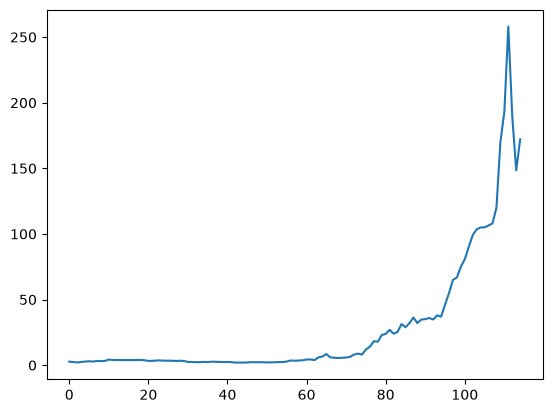

In [4]:
plt.plot(nahco_end_month_df['close_price'])
plt.show()

In [5]:
nahco_end_month_df['returns']=nahco_end_month_df['close_price'].pct_change()*100
nahco_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45433,NAHCO,2017-01-31,2.71,2.71,38324,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47256,NAHCO,2017-02-28,2.45,2.45,71232,2026-04-08T02:44:45.006295+00:00,2,1,2017,-9.594096
2,49372,NAHCO,2017-03-31,2.10,2.10,596105,2026-04-08T02:45:42.281198+00:00,3,1,2017,-14.285714
3,51199,NAHCO,2017-04-28,2.50,2.50,2071926,2026-04-08T02:51:55.619599+00:00,4,2,2017,19.047619
4,53122,NAHCO,2017-05-31,2.75,2.75,121475,2026-04-08T02:52:57.421655+00:00,5,2,2017,10.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35337,NAHCO,2026-03-31,193.00,193.00,2175728,2026-03-31T15:00:02.085058+00:00,3,1,2026,13.529412
111,281163,NAHCO,2026-04-30,258.00,258.00,5181038,2026-04-30T15:00:02.170664+00:00,4,2,2026,33.678756
112,284229,NAHCO,2026-05-29,189.50,189.50,611268,2026-05-29T15:00:02.455558+00:00,5,2,2026,-26.550388
113,294157,NAHCO,2026-06-30,148.50,148.50,1047900,2026-06-30T15:10:03.08168+00:00,6,2,2026,-21.635884


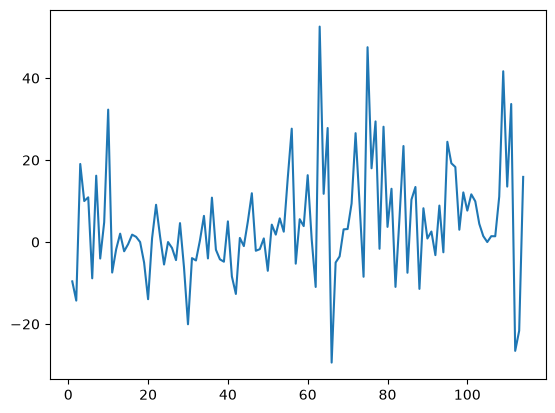

In [6]:
plt.plot(nahco_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(nahco_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-6.618316134724611), np.float64(6.126998352295836e-09), 1, 112, {'1%': np.float64(-3.4901313156261384), '5%': np.float64(-2.8877122815688776), '10%': np.float64(-2.5807296460459184)}, np.float64(809.653920578855))
stationary


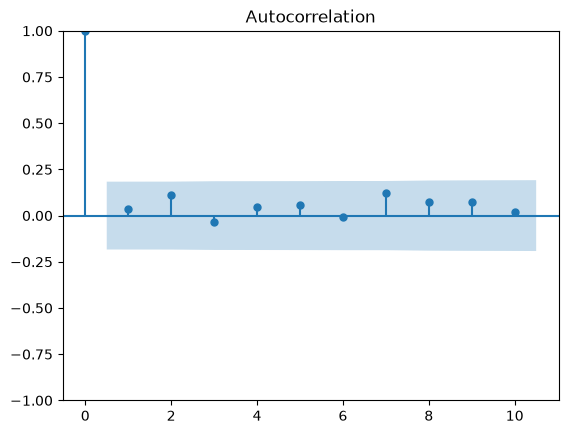

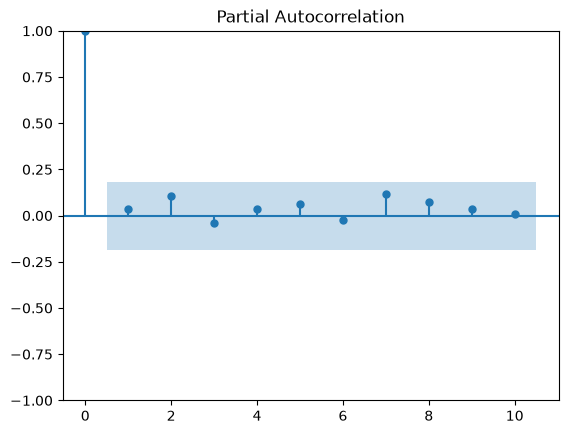

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(nahco_end_month_df['returns'].dropna(), lags=10)
plot_pacf(nahco_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nahco_end_month_df['close_price'][:-10]
test=nahco_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -11.188893007414615]
[0, 0, 0, 0, 0, 1, -6.083910262754696]
[0, 0, 0, 0, 0, 2, -4.043294209517008]
[0, 0, 0, 0, 1, 0, -3.4626930740367587]
[0, 0, 0, 0, 1, 1, -2.3665974910929948]
[0, 0, 0, 0, 1, 2, -1.688400607259525]
[0, 0, 0, 0, 2, 0, -1.1494670818207946]
[0, 0, 0, 0, 2, 1, -1.1133146918631156]
[0, 0, 0, 0, 2, 2, -0.7699288319434812]
[0, 0, 0, 1, 0, 0, -3.9728230924657417]
[0, 0, 0, 1, 0, 1, -2.8172339039507706]
[0, 0, 0, 1, 0, 2, -2.1660738680919636]
[0, 0, 0, 1, 1, 0, -1.4580994801305938]
[0, 0, 0, 1, 1, 1, -1.4363405521049182]
[0, 0, 0, 1, 1, 2, -1.1437788488947969]
[0, 0, 0, 1, 2, 0, -1.0680943480334157]
[0, 0, 0, 1, 2, 1, -0.9371310044165568]
[0, 0, 0, 1, 2, 2, -0.6914833121068473]
[0, 0, 0, 2, 0, 0, -2.041067411412894]
[0, 0, 0, 2, 0, 1, -2.008070559919858]
[0, 0, 0, 2, 0, 2, -1.7587541347711149]
[0, 0, 0, 2, 1, 0, -1.4138663824703195]
[0, 0, 0, 2, 1, 1, -1.4501528002385808]
[0, 0, 0, 2, 1, 2, -1.122215292903852]
[0, 0, 0, 2, 2, 0, -0.7031913396212417]
[0, 0,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
534,2,0,1,2,1,0,-18.259229
0,0,0,0,0,0,0,-11.188893
522,2,0,1,1,0,0,-11.188893
27,0,0,1,0,0,0,-10.860120
54,0,0,2,0,0,0,-10.454986
...,...,...,...,...,...,...,...
456,1,2,1,2,2,0,0.437568
240,0,2,2,2,2,0,0.437838
213,0,2,1,2,2,0,0.438519
177,0,2,0,1,2,0,0.438629


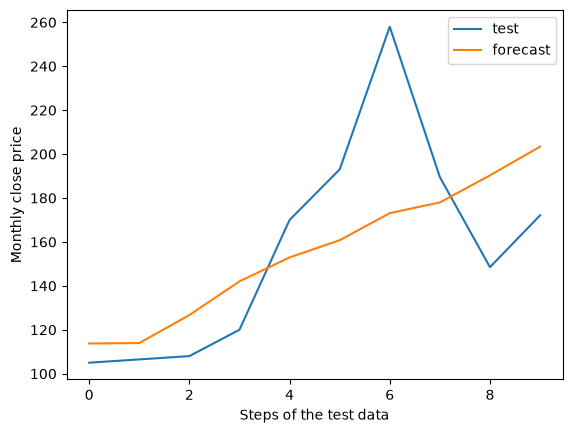

r2_score:  0.4393184250065586
rmse:  35.158486793042876
description:  count    115.000000
mean      27.736957
std       48.130305
min        2.000000
25%        2.730000
50%        3.990000
75%       31.675000
max      258.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=nahco_end_month_df['close_price'][:-10]
y_test=nahco_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,2), 
seasonal_order=(2,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nahco_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nahco_end_month_df['returns'].dropna()[:-10]
test=nahco_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.12105765808620883]
[0, 0, 0, 0, 0, 1, -0.0013921971927253196]
[0, 0, 0, 0, 0, 2, 0.012654237014004699]
[0, 0, 0, 0, 1, 0, -0.004423195109269695]
[0, 0, 0, 0, 1, 1, -0.018676500282163833]
[0, 0, 0, 0, 1, 2, -0.0330669784341846]
[0, 0, 0, 0, 2, 0, -0.6652341265543655]
[0, 0, 0, 0, 2, 1, -0.046580223921275365]
[0, 0, 0, 0, 2, 2, -0.03654250055939823]
[0, 0, 0, 1, 0, 0, 0.03821388909637258]
[0, 0, 0, 1, 0, 1, 0.0430007518511093]
[0, 0, 0, 1, 0, 2, 0.032564681883921365]
[0, 0, 0, 1, 1, 0, 0.039236917446628716]
[0, 0, 0, 1, 1, 1, -0.03648435835632391]
[0, 0, 0, 1, 1, 2, -0.030458655256845546]
[0, 0, 0, 1, 2, 0, -0.09472331463926587]
[0, 0, 0, 1, 2, 1, -0.005438162101121691]
[0, 0, 0, 1, 2, 2, -0.1013328476583848]
[0, 0, 0, 2, 0, 0, 0.04309811815227005]
[0, 0, 0, 2, 0, 1, 0.0409956257838181]
[0, 0, 0, 2, 0, 2, 0.0126894473848298]
[0, 0, 0, 2, 1, 0, -0.009528762193244278]
[0, 0, 0, 2, 1, 1, -0.02742259673691505]
[0, 0, 0, 2, 1, 2, -0.02000890493226848]
[0, 0, 0, 2, 2, 0, 

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-15.094799
186,0,2,0,2,2,0,-7.852518
420,1,2,0,1,2,0,-4.551773
429,1,2,0,2,2,0,-4.341763
672,2,2,0,2,2,0,-4.237260
...,...,...,...,...,...,...,...
380,1,1,2,0,0,2,0.056253
605,2,1,1,1,0,2,0.057158
171,0,2,0,1,0,0,0.057356
713,2,2,2,1,1,0,0.060183


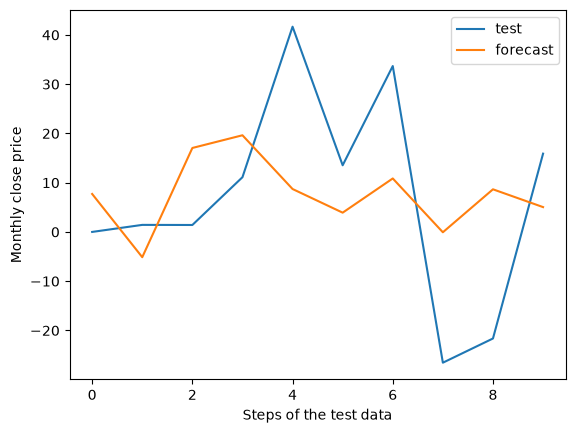

r2_score:  0.06178586030576816
rmse:  19.634610340986008
description:  count    114.000000
mean       4.547096
std       13.568661
min      -29.411765
25%       -3.818369
50%        1.927995
75%       10.890152
max       52.564103
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=nahco_end_month_df['returns'].dropna()[:-10]
y_test=nahco_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,1), 
seasonal_order=(1,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nahco_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
